In [1]:
# ============================================================
# CELL 1: Imports
# ============================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Gerät: {device}")

model, _, preprocess = open_clip.create_model_and_transforms(
    'EVA01-g-14',
    pretrained='laion400m_s11b_b41k'
)
model = model.to(device)
model.eval()
tokenizer = open_clip.get_tokenizer('EVA01-g-14')
print("Modell geladen: EVA01-CLIP-g/14")

C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gerät: cuda


C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lukas\.cache\huggingface\hub\models--timm--eva_giant_patch14_clip_224.laion400m_s11b_b41k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Modell geladen: EVA01-CLIP-g/14


In [2]:
# ============================================================
# CELL 2: Prompts
# ============================================================
categories = ["indoor", "outdoor"]

category_texts = [
    "a photo taken inside a room showing walls, ceiling, furniture, artificial lighting or floor",
    "a photo taken outdoors showing open spaces such as nature, sky, streets, buildings, parks or landscapes"
]

text_tokens = tokenizer(category_texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Kategorien:", categories)
print("Text-Embeddings berechnet:", text_features.shape)

Kategorien: ['indoor', 'outdoor']
Text-Embeddings berechnet: torch.Size([2, 1024])


In [3]:
# ============================================================
# CELL 3: Pfade
# ============================================================
image_folder = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = []

for subfolder in ['indoor', 'outdoor']:
    folder = os.path.join(image_folder, subfolder)
    if not os.path.exists(folder):
        print(f'⚠ Ordner nicht gefunden: {folder}')
        continue
    for fname in sorted(os.listdir(folder)):
        if fname.startswith("augmented_"):
            continue
        ext = os.path.splitext(fname)[1].lower()
        if ext not in VALID_EXTENSIONS:
            continue
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)

print(f"Bilder gefunden: {len(image_paths)}")

Bilder gefunden: 700


In [4]:
# ============================================================
# CELL 4: Klassifikation
# ============================================================
def safe_open(path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"  ⚠ Skipped ({os.path.basename(path)}): {e}")
        return None

BATCH_SIZE = 16  # EVA ist größer → kleinere Batches

results     = []
confidences = []
valid_paths = []

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Batches"):
    batch_paths = image_paths[i : i + BATCH_SIZE]
    loaded      = [(p, safe_open(p)) for p in batch_paths]
    loaded      = [(p, img) for p, img in loaded if img is not None]

    if not loaded:
        continue

    paths_ok, imgs_ok = zip(*loaded)

    img_tensors = torch.stack([preprocess(img) for img in imgs_ok]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(img_tensors)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarities = image_features @ text_features.T
    batch_preds  = similarities.argmax(dim=1).cpu().numpy()
    batch_conf   = similarities.max(dim=1).values.cpu().float().numpy()

    results.extend([categories[idx] for idx in batch_preds])
    confidences.extend(batch_conf)
    valid_paths.extend(paths_ok)

print(f"\nKlassifiziert: {len(results)} Bilder")
print("\nVorhersage-Verteilung:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)}")

Batches: 100%|██████████████████████████████████████████████████████████████████████| 44/44 [2:16:42<00:00, 186.41s/it]


Klassifiziert: 700 Bilder

Vorhersage-Verteilung:
  indoor: 251
  outdoor: 449


In [5]:
# ============================================================
# CELL 5: Bilder sortieren
# ============================================================
output_base = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted"

sorted_dirs = {cat: os.path.join(output_base, cat) for cat in categories}
for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

for path, pred in zip(valid_paths, results):
    shutil.copy(path, sorted_dirs[pred])

print("Bilder sortiert:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)} → {sorted_dirs[cat]}")

Bilder sortiert:
  indoor: 251 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\indoor
  outdoor: 449 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\outdoor


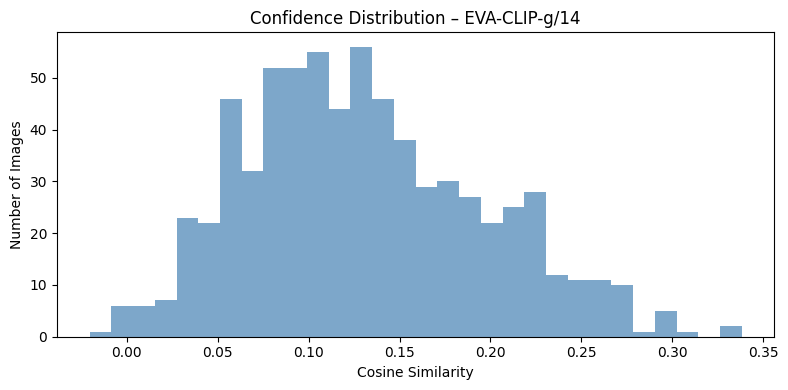

In [6]:
# ============================================================
# CELL 6: Konfidenz visualisieren
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(confidences, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution – EVA-CLIP-g/14")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: CSV speichern
# ============================================================
output_csv = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\evaclip_labels.csv"

df_results = pd.DataFrame({
    "file_name":  [os.path.basename(p) for p in valid_paths],
    "pred_label": results,
    "confidence": confidences
})

df_results.to_csv(output_csv, index=False)
print(f"Labels gespeichert: {output_csv}")
print()
print("Verteilung:")
print(df_results["pred_label"].value_counts())
print(f"\nGesamt: {len(df_results)} Bilder")

Labels gespeichert: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\evaclip_labels.csv

Verteilung:
pred_label
outdoor    449
indoor     251
Name: count, dtype: int64

Gesamt: 700 Bilder


In [8]:
# ============================================================
# CELL 8: Unsicherste Bilder
# ============================================================
df_uncertain = df_results.nsmallest(10, "confidence")
print(df_uncertain)

          file_name pred_label  confidence
530   image_960.jpg    outdoor   -0.020527
394   image_947.jpg    outdoor   -0.004350
531   image_961.jpg    outdoor   -0.003761
108  image_3247.jpg     indoor   -0.000772
323  image_8661.jpg    outdoor    0.000050
131  image_3996.jpg     indoor    0.001491
275  image_7426.jpg     indoor    0.001491
143  image_4179.jpg     indoor    0.005140
296  image_7662.jpg     indoor    0.005140
85   image_2920.jpg    outdoor    0.008724


Evaluierbare Bilder: 700

Accuracy:              0.8500
Ø Confidence (Cosine): 0.1306

              precision    recall  f1-score   support

      indoor       0.99      0.71      0.83       350
     outdoor       0.77      0.99      0.87       350

    accuracy                           0.85       700
   macro avg       0.88      0.85      0.85       700
weighted avg       0.88      0.85      0.85       700



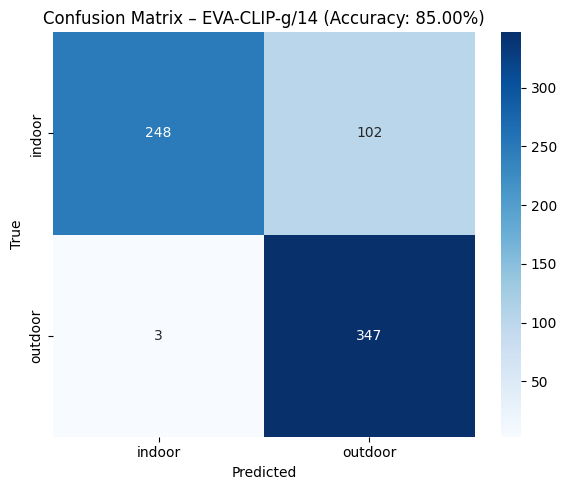

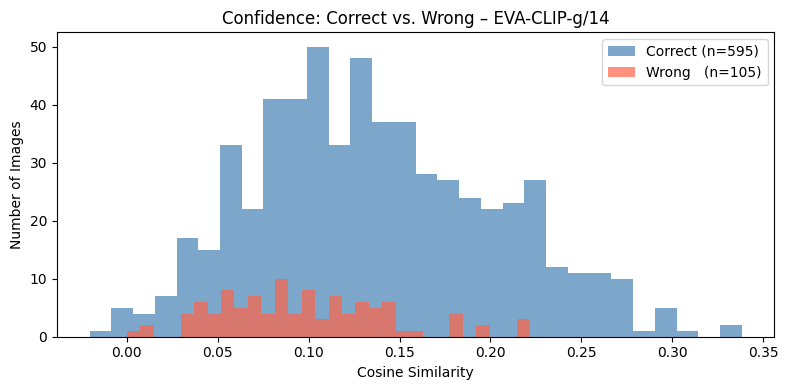


Unsicherste 10 Bilder:
          file_name true_label pred_label  confidence
530   image_960.jpg    outdoor    outdoor   -0.020527
394   image_947.jpg    outdoor    outdoor   -0.004350
531   image_961.jpg    outdoor    outdoor   -0.003761
108  image_3247.jpg     indoor     indoor   -0.000772
323  image_8661.jpg     indoor    outdoor    0.000050
131  image_3996.jpg     indoor     indoor    0.001491
275  image_7426.jpg     indoor     indoor    0.001491
143  image_4179.jpg     indoor     indoor    0.005140
296  image_7662.jpg     indoor     indoor    0.005140
85   image_2920.jpg     indoor    outdoor    0.008724

── Alle Dateien gespeichert in: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\evaluation ──


In [9]:
# ============================================================
# CELL 9: Evaluation mit Ground Truth Labels
# ============================================================
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

output_dir = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\evaclip_sorted\evaluation"
os.makedirs(output_dir, exist_ok=True)

label_csv   = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted\photo_labels_indoor_outdoor.csv"
df_labels   = pd.read_csv(label_csv)
labels_dict = dict(zip(df_labels["file_name"], df_labels["Main_focus"]))

df_results["true_label"] = df_results["file_name"].map(labels_dict)
df_eval = df_results.dropna(subset=["true_label"])
print(f"Evaluierbare Bilder: {len(df_eval)}")

true     = df_eval["true_label"].values
pred     = df_eval["pred_label"].values
accuracy = accuracy_score(true, pred)
avg_conf = float(np.mean(df_eval["confidence"]))

print(f"\nAccuracy:              {accuracy:.4f}")
print(f"Ø Confidence (Cosine): {avg_conf:.4f}")
print()
print(classification_report(true, pred, target_names=sorted(categories)))

pd.DataFrame(
    classification_report(true, pred,
                          target_names=sorted(categories),
                          output_dict=True)
).transpose().to_csv(os.path.join(output_dir, "evaclip_metrics.csv"))

le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(true), le.transform(pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – EVA-CLIP-g/14 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "evaclip_confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()

correct      = (df_eval["true_label"] == df_eval["pred_label"]).tolist()
conf_correct = [c for c, ok in zip(df_eval["confidence"], correct) if ok]
conf_wrong   = [c for c, ok in zip(df_eval["confidence"], correct) if not ok]

plt.figure(figsize=(8, 4))
plt.hist(conf_correct, bins=30, alpha=0.7,
         label=f"Correct (n={len(conf_correct)})", color="steelblue")
plt.hist(conf_wrong,   bins=30, alpha=0.7,
         label=f"Wrong   (n={len(conf_wrong)})",   color="tomato")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence: Correct vs. Wrong – EVA-CLIP-g/14")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "evaclip_confidence_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

df_uncertain = df_eval.nsmallest(10, "confidence")[
    ["file_name", "true_label", "pred_label", "confidence"]]
print("\nUnsicherste 10 Bilder:")
print(df_uncertain)
df_uncertain.to_csv(os.path.join(output_dir, "evaclip_most_uncertain.csv"), index=False)

print(f"\n── Alle Dateien gespeichert in: {output_dir} ──")